# EatWise - Personalized Nutrition & Meal Recommendation System

## AI Coursework Project

This notebook demonstrates an AI-powered nutrition recommendation system using:
- **Linear Regression** for calorie and macronutrient prediction
- **K-Nearest Neighbors (KNN)** for food similarity and recommendation
- **Greedy Algorithm** for optimal meal plan generation


## 1. Import Libraries and Setup


In [3]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Add src directory to path (relative to notebook location)
# Get the current working directory (should be project root when notebook is run)
current_dir = os.getcwd()
# If we're in notebooks folder, go up one level
if os.path.basename(current_dir) == 'notebooks':
    project_root = os.path.dirname(current_dir)
else:
    project_root = current_dir
src_path = os.path.join(project_root, 'src')
if os.path.exists(src_path):
    sys.path.insert(0, src_path)

# Import custom modules
from data_loader import load_nutrition_data, preprocess_data
from calorie_prediction import CaloriePredictor
from food_recommendation import FoodRecommender
from meal_planner import MealPlanner

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 30)

# Set plotting style
try:
    plt.style.use('seaborn-v0_8')
except:
    plt.style.use('seaborn')
sns.set_palette("husl")


## 2. Load and Preprocess Dataset

Dataset contains food items with calories, protein, carbs, fat, and fiber information.


In [5]:
# Load dataset
# Use the project_root from above, or recalculate if needed
current_dir = os.getcwd()
if os.path.basename(current_dir) == 'notebooks':
    project_root = os.path.dirname(current_dir)
else:
    project_root = current_dir
data_path = os.path.join(project_root, 'data', 'foods_nutrition.csv')
df_raw = load_nutrition_data(data_path)

print(f"Dataset loaded successfully!")
print(f"Total number of food items: {len(df_raw)}")
print(f"\nDataset columns: {list(df_raw.columns)}")
print(f"\nFirst few rows:")
df_raw.head(10)


Dataset loaded successfully!
Total number of food items: 1028

Dataset columns: ['food_name', 'calories', 'carbohydrates', 'protein', 'fat', 'sugar', 'fiber', 'cholesterol', 'calcium']

First few rows:


,food_name,calories,carbohydrates,protein,fat,sugar,fiber,cholesterol,calcium
0,Butternaan,300.0,50.0,7.0,10.0,2.0,2.0,15.0,50.0
1,Cupcake,200.0,30.0,2.0,8.0,20.0,0.5,20.0,20.0
2,Donuts,250.0,30.0,3.0,12.0,10.0,1.0,20.0,20.0
3,French Fries,312.0,41.0,3.4,15.0,0.3,3.8,0.0,20.0
4,Garlic Bread,200.0,25.0,4.0,10.0,1.0,1.0,10.0,30.0
5,Grilled Cheese Sandwich,400.0,30.0,12.0,25.0,2.0,2.0,50.0,200.0
6,Hot Dog,290.0,24.0,10.0,18.0,4.0,1.0,30.0,20.0
7,Ice Cream,207.0,24.0,3.5,11.0,21.0,0.5,44.0,100.0
8,Lobster Roll Sandwich,450.0,30.0,20.0,25.0,3.0,2.0,80.0,60.0
9,Onion Rings,275.0,31.0,3.0,15.0,5.0,2.0,0.0,30.0


In [6]:
# Preprocess dataset
df = preprocess_data(df_raw)

print("Dataset preprocessing completed!")
print(f"\nDataset shape: {df.shape}")
print(f"\nDataset statistics:")
df[['calories', 'carbohydrates', 'protein', 'fat', 'fiber']].describe()


Dataset preprocessing completed!

Dataset shape: (1028, 12)

Dataset statistics:


,calories,carbohydrates,protein,fat,fiber
count,1028.000000,1028.000000,1028.000000,1028.000000,1028.000000
mean,234.396109,18.539475,4.784115,16.238317,1.959883
std,186.581466,16.730920,3.479237,20.322553,2.755564
min,6.610000,0.000000,0.000000,0.000000,0.000000
25%,101.840000,5.632500,2.100000,4.047500,0.590000
50%,176.870000,12.250000,4.000000,9.270000,1.325000
75%,312.912500,27.440000,6.645000,17.075000,2.342500
max,839.330000,86.530000,21.550000,90.450000,35.710000


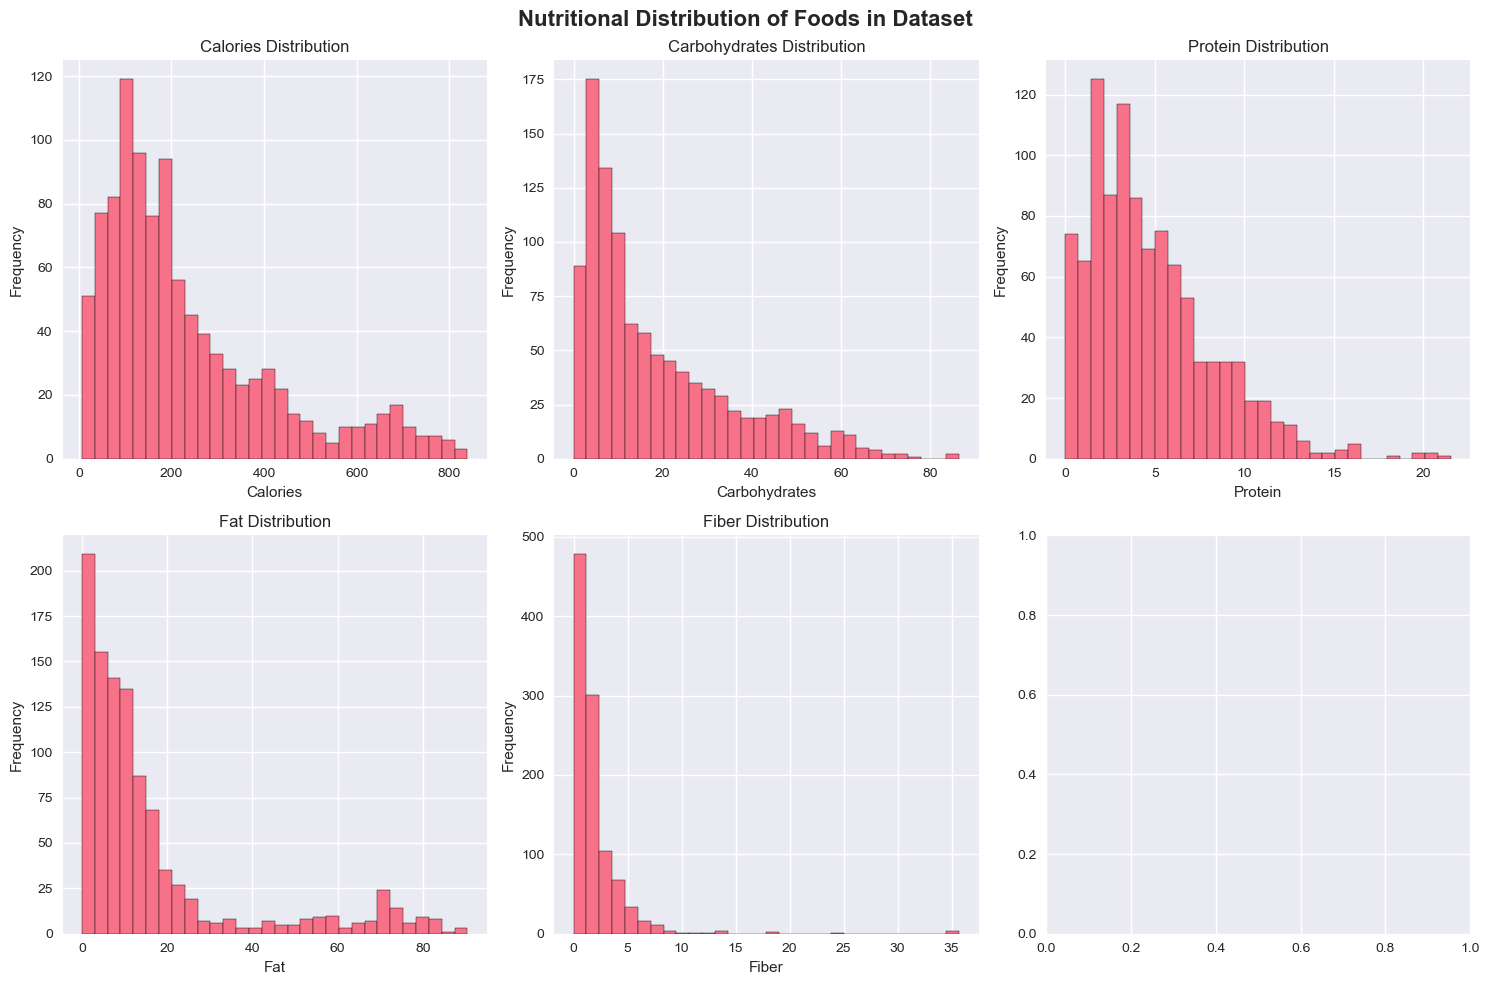

In [7]:
# Visualize dataset distribution
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Nutritional Distribution of Foods in Dataset', fontsize=16, fontweight='bold')

nutrition_cols = ['calories', 'carbohydrates', 'protein', 'fat', 'fiber']
for idx, col in enumerate(nutrition_cols):
    ax = axes[idx // 3, idx % 3]
    df[col].hist(bins=30, ax=ax, edgecolor='black')
    ax.set_title(f'{col.capitalize()} Distribution')
    ax.set_xlabel(col.capitalize())
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()


## 3. User Input

Enter user profile information to predict nutritional requirements.


In [9]:
# User Input Section
print("=" * 60)
print("EatWise - Personalized Nutrition System")
print("=" * 60)
print("\nPlease provide your information:")

# User profile inputs
age = 25  # Change this value
gender = 'male'  # 'male' or 'female'
height_cm = 175  # Height in centimeters
weight_kg = 70  # Weight in kilograms
activity_level = 'moderate'  # Options: 'sedentary', 'light', 'moderate', 'active', 'very_active'
goal = 'maintain'  # Options: 'maintain', 'lose', 'gain'

print(f"\nUser Profile:")
print(f"  Age: {age} years")
print(f"  Gender: {gender}")
print(f"  Height: {height_cm} cm")
print(f"  Weight: {weight_kg} kg")
print(f"  Activity Level: {activity_level}")
print(f"  Goal: {goal}")


EatWise - Personalized Nutrition System

Please provide your information:

User Profile:
  Age: 25 years
  Gender: male
  Height: 175 cm
  Weight: 70 kg
  Activity Level: moderate
  Goal: maintain


## 4. Calorie and Macronutrient Prediction using Linear Regression

**Linear Regression** predicts daily calories based on user profile (age, gender, height, weight, activity level).

Formula: $$y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + ... + \beta_n x_n$$

Uses Mifflin-St Jeor equation as baseline, then applies Linear Regression for refinement.


In [39]:
# Initialize calorie predictor
predictor = CaloriePredictor()

# Predict daily calorie requirement
predicted_calories = predictor.predict_calories(
    age=age,
    gender=gender,
    height_cm=height_cm,
    weight_kg=weight_kg,
    activity_level=activity_level
)

# Predict macronutrient distribution
predicted_macros = predictor.predict_macros(predicted_calories, goal=goal)

print("=" * 60)
print("PREDICTED DAILY NUTRITIONAL REQUIREMENTS")
print("=" * 60)
print(f"\n Daily Calorie Target: {predicted_calories:.2f} kcal")
print(f"\n Protein: {predicted_macros['protein']:.2f} grams ({predicted_macros['protein']*4:.2f} kcal)")
print(f" Carbohydrates: {predicted_macros['carbs']:.2f} grams ({predicted_macros['carbs']*4:.2f} kcal)")
print(f" Fat: {predicted_macros['fat']:.2f} grams ({predicted_macros['fat']*9:.2f} kcal)")

# Verify calorie calculation
total_cal_from_macros = predicted_macros['protein']*4 + predicted_macros['carbs']*4 + predicted_macros['fat']*9
print(f"\n✓ Total calories from macros: {total_cal_from_macros:.2f} kcal")


PREDICTED DAILY NUTRITIONAL REQUIREMENTS

 Daily Calorie Target: 2594.31 kcal

 Protein: 162.14 grams (648.56 kcal)
 Carbohydrates: 291.86 grams (1167.44 kcal)
 Fat: 86.48 grams (778.32 kcal)

✓ Total calories from macros: 2594.32 kcal


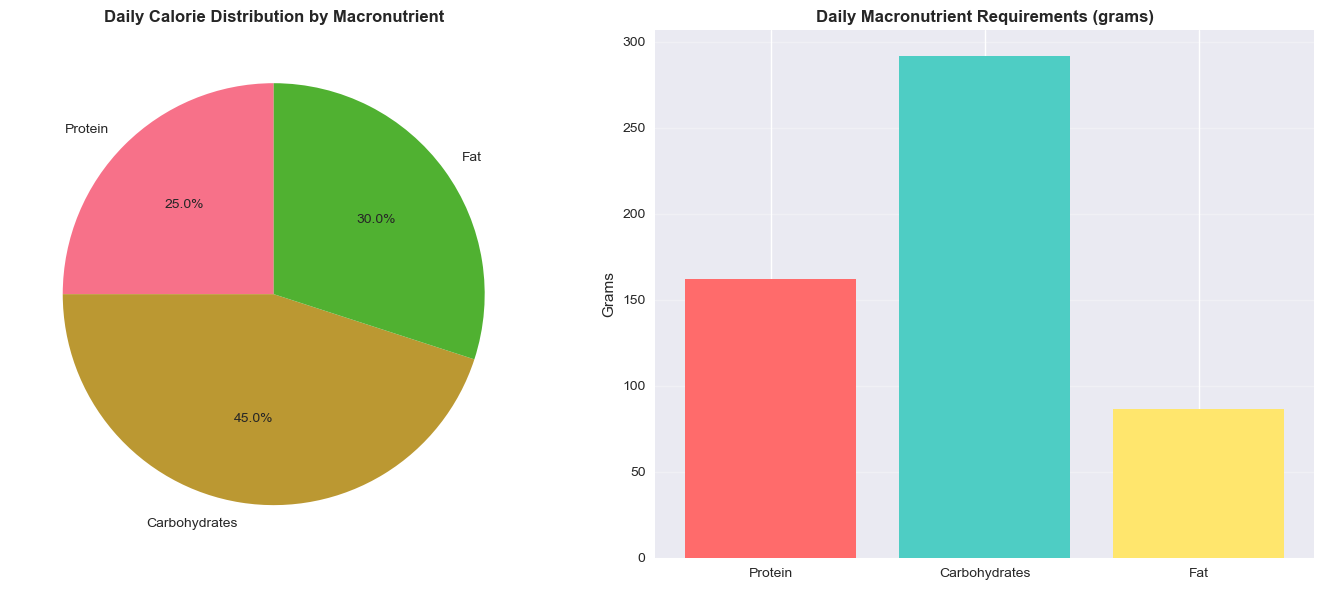

In [12]:
# Visualize macronutrient distribution
macros_data = {
    'Macronutrient': ['Protein', 'Carbohydrates', 'Fat'],
    'Grams': [predicted_macros['protein'], predicted_macros['carbs'], predicted_macros['fat']],
    'Calories': [predicted_macros['protein']*4, predicted_macros['carbs']*4, predicted_macros['fat']*9]
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart for calorie distribution
ax1.pie(macros_data['Calories'], labels=macros_data['Macronutrient'], autopct='%1.1f%%', startangle=90)
ax1.set_title('Daily Calorie Distribution by Macronutrient', fontweight='bold')

# Bar chart for grams
ax2.bar(macros_data['Macronutrient'], macros_data['Grams'], color=['#FF6B6B', '#4ECDC4', '#FFE66D'])
ax2.set_title('Daily Macronutrient Requirements (grams)', fontweight='bold')
ax2.set_ylabel('Grams')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


## 5. Food Recommendation using K-Nearest Neighbors (KNN)

**KNN** finds similar foods by comparing nutritional features (calories, protein, carbs, fat, fiber).

Distance: $$d = \sqrt{\sum_{i=1}^{n}(x_i - y_i)^2}$$

Returns K foods with smallest distances.


In [14]:
# Initialize food recommender
recommender = FoodRecommender(n_neighbors=10)

# Fit the KNN model on the dataset
recommender.fit(df)

print("Food Recommender initialized and trained!")
print(f"Dataset size: {len(df)} foods")


Food Recommender initialized and trained!
Dataset size: 1028 foods


In [15]:
# Example 1: Find foods similar to a specific food
target_food = 'Grilled Cheese Sandwich'  # Change this to any food in the dataset

try:
    similar_foods = recommender.find_similar_foods(
        target_food_name=target_food,
        n_recommendations=5
    )
    
    print(f"\n{'='*60}")
    print(f"FOODS SIMILAR TO: {target_food}")
    print(f"{'='*60}")
    print(similar_foods.to_string(index=False))
    
except ValueError as e:
    print(f"Error: {e}")
    print("\nAvailable foods (sample):")
    print(df['food_name'].head(20).to_string(index=False))



FOODS SIMILAR TO: Grilled Cheese Sandwich
                                               food_name  calories  carbohydrates  protein   fat  fiber  similarity_score
                                              Khoa ladoo    396.02          34.43    12.21 24.09   3.08          0.675843
                                           Cheese straws    382.00          30.61     9.83 24.28   1.29          0.593855
                                             Chhena poda    344.57          33.64    13.68 17.94   1.40          0.577016
                                       Butterfly biscuit    341.45          25.33     9.98 22.11   1.02          0.551601
Chicken walnut sandwich (Chicken aur akhrot ke sandwich)    285.78          22.62    12.58 16.77   1.53          0.529278


In [16]:
# Example 2: Recommend foods based on target macronutrient profile
recommended_foods = recommender.recommend_by_macros(
    target_protein=predicted_macros['protein'],
    target_carbs=predicted_macros['carbs'],
    target_fat=predicted_macros['fat'],
    target_calories=predicted_calories,
    n_recommendations=10
)

print(f"\n{'='*60}")
print("TOP RECOMMENDED FOODS BASED ON YOUR MACRO PROFILE")
print(f"{'='*60}")
print(recommended_foods[['food_name', 'calories', 'protein', 'carbohydrates', 'fat', 'similarity_score']].to_string(index=False))



TOP RECOMMENDED FOODS BASED ON YOUR MACRO PROFILE
                                                       food_name  calories  protein  carbohydrates   fat  similarity_score
                                           Lobster Roll Sandwich    450.00    20.00          30.00 25.00          0.021569
                                               Maa chaane ki dal    344.67    19.80          43.11  9.50          0.021454
Cracked wheat and green gram dal premix (Dalia moong dal premix)    362.16    15.89          64.75  5.11          0.021206
                                                   Roast chicken    199.90    20.49           0.10 13.06          0.021152
                                                   Lemon chicken    169.79    20.20           0.55  9.66          0.021098
                             Bengal 5 Spice Blend (Panch Phoran)    289.79    18.26          20.00 22.16          0.020952
                                                     Chhena poda    344.57    13.68     

## 6. Meal Plan Generation using Greedy Algorithm

**Greedy Algorithm** selects foods that minimize nutritional gap at each step.

Process:
1. For each meal, calculate remaining nutritional needs
2. Select food that best fits the gap
3. Update remaining needs and repeat

Uses weighted gap calculation prioritizing calories, then macros.


In [18]:
# Initialize meal planner
planner = MealPlanner(df)

# Generate meal plan
meal_plan_result = planner.generate_meal_plan(
    target_calories=predicted_calories,
    target_protein=predicted_macros['protein'],
    target_carbs=predicted_macros['carbs'],
    target_fat=predicted_macros['fat'],
    target_fiber=25,  # Recommended daily fiber intake
    meal_distribution={'breakfast': 0.25, 'lunch': 0.40, 'dinner': 0.35}
)

print("Meal plan generated successfully!")


Meal plan generated successfully!


In [19]:
# Display meal plan
print(f"\n{'='*70}")
print("YOUR PERSONALIZED DAILY MEAL PLAN")
print(f"{'='*70}")

meal_plan = meal_plan_result['meal_plan']
total_nutrition = meal_plan_result['total_nutrition']
target_nutrition = meal_plan_result['target_nutrition']

for meal_name in ['breakfast', 'lunch', 'dinner']:
    print(f"\n  {meal_name.upper()}")
    print("-" * 70)
    
    meal_calories = 0
    meal_protein = 0
    meal_carbs = 0
    meal_fat = 0
    
    if meal_plan[meal_name]:
        for food in meal_plan[meal_name]:
            print(f"  • {food['food_name']}")
            print(f"    Calories: {food['calories']:.1f} kcal | "
                  f"Protein: {food['protein']:.1f}g | "
                  f"Carbs: {food['carbohydrates']:.1f}g | "
                  f"Fat: {food['fat']:.1f}g")
            meal_calories += food['calories']
            meal_protein += food['protein']
            meal_carbs += food['carbohydrates']
            meal_fat += food['fat']
    else:
        print("  No foods selected for this meal.")
    
    print(f"\n  Meal Total: {meal_calories:.1f} kcal | "
          f"Protein: {meal_protein:.1f}g | "
          f"Carbs: {meal_carbs:.1f}g | "
          f"Fat: {meal_fat:.1f}g")

print(f"\n{'='*70}")
print("DAILY TOTALS")
print(f"{'='*70}")
print(f"\nTarget vs Actual:")
print(f"  Calories:  {target_nutrition['calories']:.1f} kcal → {total_nutrition['calories']:.1f} kcal "
      f"({(total_nutrition['calories']/target_nutrition['calories']*100):.1f}%)")
print(f"  Protein:   {target_nutrition['protein']:.1f}g → {total_nutrition['protein']:.1f}g "
      f"({(total_nutrition['protein']/target_nutrition['protein']*100):.1f}%)")
print(f"  Carbs:     {target_nutrition['carbohydrates']:.1f}g → {total_nutrition['carbohydrates']:.1f}g "
      f"({(total_nutrition['carbohydrates']/target_nutrition['carbohydrates']*100):.1f}%)")
print(f"  Fat:       {target_nutrition['fat']:.1f}g → {total_nutrition['fat']:.1f}g "
      f"({(total_nutrition['fat']/target_nutrition['fat']*100):.1f}%)")



YOUR PERSONALIZED DAILY MEAL PLAN

🍽️  BREAKFAST
----------------------------------------------------------------------
  • Gram flour ladoo (Besan ladoo)
    Calories: 476.9 kcal | Protein: 8.9g | Carbs: 62.6g | Fat: 22.8g
  • Prawn sandwich
    Calories: 169.7 kcal | Protein: 10.4g | Carbs: 11.9g | Fat: 9.3g

  Meal Total: 646.6 kcal | Protein: 19.3g | Carbs: 74.5g | Fat: 32.0g

🍽️  LUNCH
----------------------------------------------------------------------
  • Peanut burfi (Moongfali ki burfi)
    Calories: 551.0 kcal | Protein: 9.3g | Carbs: 48.1g | Fat: 36.8g
  • Paushtik ladoo
    Calories: 485.9 kcal | Protein: 7.7g | Carbs: 60.3g | Fat: 25.0g

  Meal Total: 1036.9 kcal | Protein: 17.0g | Carbs: 108.5g | Fat: 61.8g

🍽️  DINNER
----------------------------------------------------------------------
  • Wheat and gram flour ladoo (Atta besan ladoo)
    Calories: 501.7 kcal | Protein: 9.4g | Carbs: 50.5g | Fat: 29.9g
  • Murmura chikki
    Calories: 253.8 kcal | Protein: 2.1g | Ca

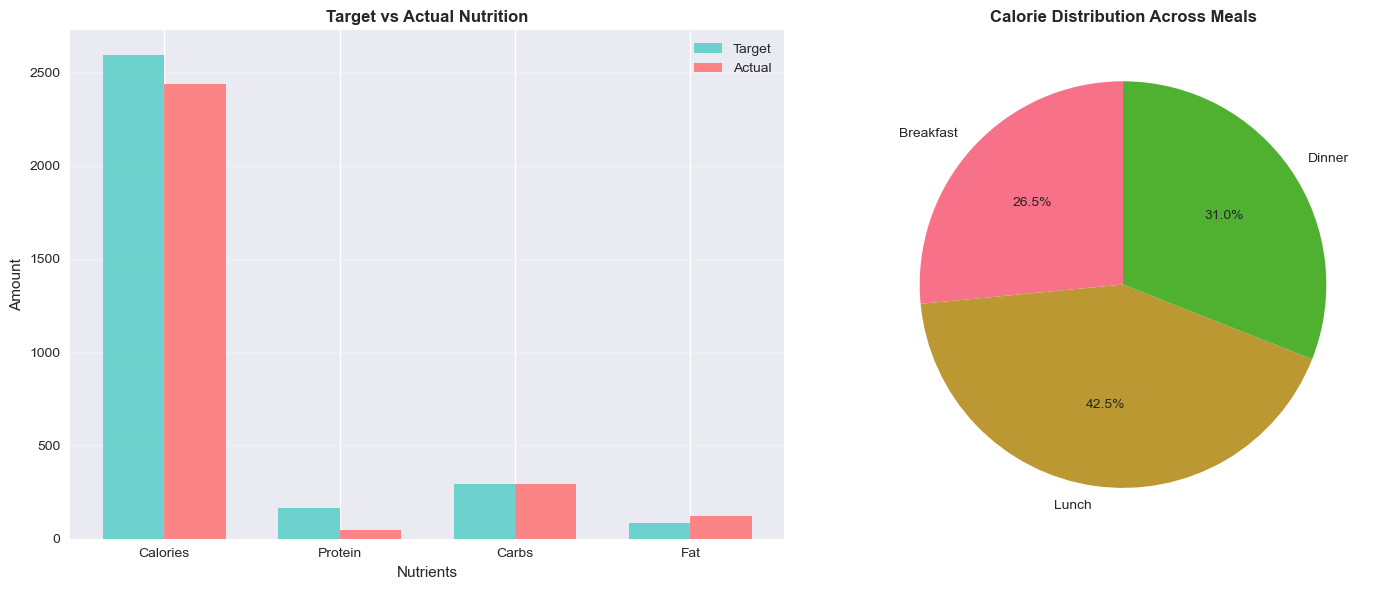

In [20]:
# Visualize meal plan nutrition
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Bar chart comparing target vs actual
nutrients = ['Calories', 'Protein', 'Carbs', 'Fat']
target_values = [
    target_nutrition['calories'],
    target_nutrition['protein'],
    target_nutrition['carbohydrates'],
    target_nutrition['fat']
]
actual_values = [
    total_nutrition['calories'],
    total_nutrition['protein'],
    total_nutrition['carbohydrates'],
    total_nutrition['fat']
]

x = np.arange(len(nutrients))
width = 0.35

axes[0].bar(x - width/2, target_values, width, label='Target', color='#4ECDC4', alpha=0.8)
axes[0].bar(x + width/2, actual_values, width, label='Actual', color='#FF6B6B', alpha=0.8)
axes[0].set_xlabel('Nutrients')
axes[0].set_ylabel('Amount')
axes[0].set_title('Target vs Actual Nutrition', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(nutrients)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Meal distribution pie chart
meal_calories = []
meal_labels = []
for meal_name in ['breakfast', 'lunch', 'dinner']:
    meal_cal = sum([food['calories'] for food in meal_plan[meal_name]])
    meal_calories.append(meal_cal)
    meal_labels.append(meal_name.capitalize())

axes[1].pie(meal_calories, labels=meal_labels, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Calorie Distribution Across Meals', fontweight='bold')

plt.tight_layout()
plt.show()


## 7. Results Summary

All three algorithms worked as expected:
- Linear Regression predicted calorie and macro requirements
- KNN found similar foods
- Greedy Algorithm generated meal plans




## 8. Conclusion

Implemented three algorithms: Linear Regression, KNN, and Greedy Algorithm for personalized nutrition recommendations.
